In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
from matplotlib import pyplot as plt

import numpy as np

from aquacrop_slovenia.reading_data import get_climate
from aquacrop_slovenia.yield_projections import run_model_projection

In [43]:
temperatures, eto, precip = get_climate("rakican", "model4", "rcp45")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/data/processed/climate/rakican_model4_rcp45.pkl'

In [44]:
plt.plot(precip)

NameError: name 'precip' is not defined

In [45]:
result = run_model_projection("rakican", "model4", "rcp26")

Setting up working directory at: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/models/testing3
Running AquaCrop simulation with project file: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/models/testing3/LIST/PROJECT.PRM
Detected platform: darwin (arm64)
Looking for executable at: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/.venv/lib/python3.14/site-packages/model/macOS/aquacrop
Using AquaCrop executable: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/models/testing3/aquacrop
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [46]:
result

,Year1,Y(dry)
0,1981,9.425
1,1982,10.940
2,1983,8.015
3,1984,9.150
4,1985,10.146
...,...,...
114,2095,5.802
115,2096,10.799
116,2097,0.308
117,2098,11.908


<Axes: xlabel='Year1'>

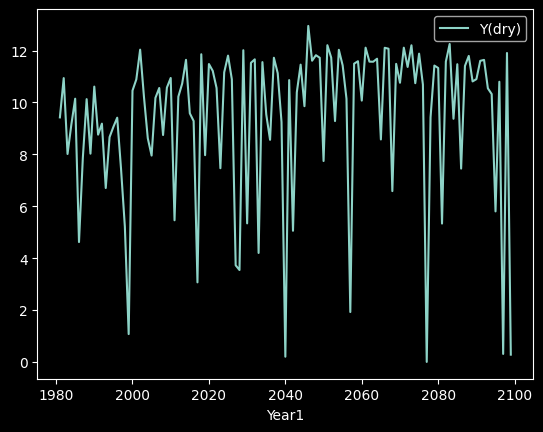

In [47]:
result.plot(x="Year1", y="Y(dry)", kind="line")

## 30-year period statistics

In [48]:
import pandas as pd

periods = {
    "1981-2010": (1981, 2010),
    "2011–2040": (2011, 2040),
    "2041–2070": (2041, 2070),
    "2071–2100": (2071, 2100),
}

rows = []
for label, (start, end) in periods.items():
    s = result.loc[(result["Year1"] >= start) & (result["Year1"] <= end), "Y(dry)"]
    rows.append({
        "Period": label,
        "Mean": s.mean(),
        "Std": s.std(),
        "Min": s.min(),
        "Median": s.median(),
        "Max": s.max(),
    })

stats_df = pd.DataFrame(rows).set_index("Period").round(3)
stats_df

,Mean,Std,Min,Median,Max
Period,,,,,
1981-2010,8.854,2.228,1.073,9.168,12.036
2011–2040,8.946,3.290,0.201,10.392,12.015
2041–2070,10.464,2.391,1.923,11.492,12.951
2071–2100,9.544,3.659,0.000,10.900,12.255


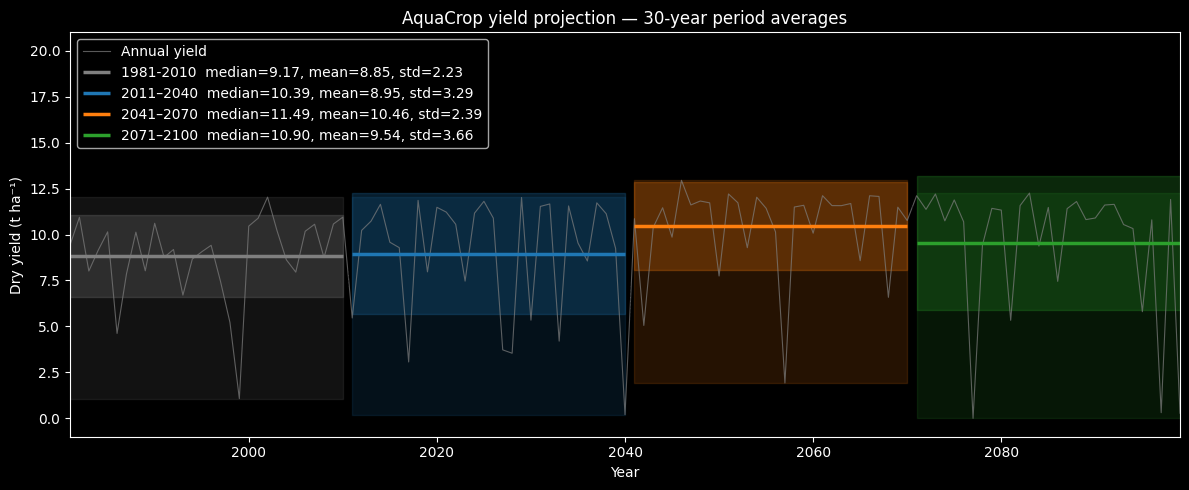

In [50]:
colors = ["tab:gray", "tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(result["Year1"], result["Y(dry)"], color="gray", linewidth=0.8, alpha=0.7, label="Annual yield")

for (label, (start, end)), color in zip(periods.items(), colors):
    s = result.loc[(result["Year1"] >= start) & (result["Year1"] <= end), "Y(dry)"]
    mean, std, median = s.mean(), s.std(), s.median()
    ax.hlines(mean, start, end, color=color, linewidth=2.5, label=f"{label}  median={median:.2f}, mean={mean:.2f}, std={std:.2f}")
    ax.fill_between(range(start, end + 1), s.min(), s.max(), color=color, alpha=0.15, label="_")
    ax.fill_between(range(start, end + 1), mean - std, mean + std, color=color, alpha=0.25, label="_")
    ax.vlines(start - 0.5, 0, 20, color="black", linewidth=0.5, linestyle="--", alpha=0.4)

ax.set_xlabel("Year")
ax.set_ylabel("Dry yield (t ha⁻¹)")
ax.set_title("AquaCrop yield projection — 30-year period averages")
ax.legend(loc="upper left")
ax.set_xlim(result["Year1"].min(), result["Year1"].max())
fig.tight_layout()
plt.show()

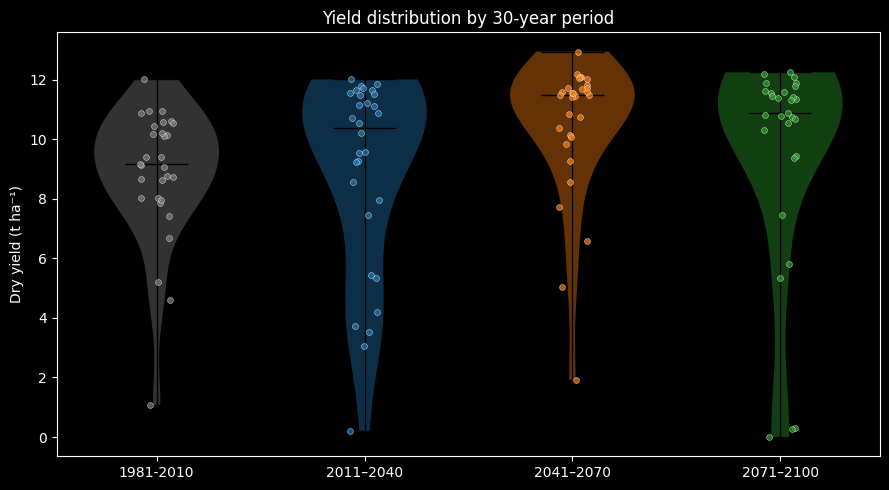

In [56]:
period_labels = list(periods.keys())
period_data = [
    result.loc[(result["Year1"] >= start) & (result["Year1"] <= end), "Y(dry)"].values
    for _, (start, end) in periods.items()
]
colors = ["tab:gray", "tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(9, 5))

parts = ax.violinplot(period_data, positions=range(len(period_labels)), widths=0.6, showmedians=True)
for pc, color in zip(parts["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.4)
for key in ("cmedians", "cbars", "cmins", "cmaxes"):
    parts[key].set_color("black")
    parts[key].set_linewidth(1)

rng = np.random.default_rng(0)
for i, (data, color) in enumerate(zip(period_data, colors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(i + jitter, data, color=color, s=18, alpha=0.7, zorder=3, edgecolors="white", linewidths=0.4)

ax.set_xticks(range(len(period_labels)))
ax.set_xticklabels(period_labels)
ax.set_ylabel("Dry yield (t ha⁻¹)")
ax.set_title("Yield distribution by 30-year period")
fig.tight_layout()
plt.show()